# Tanzania EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load Data

In [2]:
df = pd.read_csv("../data/tanzania.csv")
df["Country"] = "Tanzania"
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania


In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


## Clean

In [4]:
df.replace(-999, np.nan, inplace=True)

In [5]:
print(df.duplicated(), '\n')
print(f"How many duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates()

0       False
1       False
2       False
3       False
4       False
        ...  
4103    False
4104    False
4105    False
4106    False
4107    False
Length: 4108, dtype: bool 

How many duplicates: 0


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


# Summary statistics
this is the summmary statistics of all numeric columns

In [7]:
missing = df.isna().sum()#this will give us the percentage of missing values in each column
missing_percent = (missing/len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

if high_missing.empty:
    summary = pd.DataFrame(
        {
            "Missing Count": missing,
            "Missing Percent": missing_percent
        }
    )
    display(summary)

,Missing Count,Missing Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Outliers

In [8]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols].dropna(),nan_policy='omit'))
z_df = pd.DataFrame(z_scores, index=df[cols].dropna().index, columns=cols)

outlier_mask = (z_scores > 3).any(axis=1)
print((z_scores > 3).sum())


102


### Outlier Treatment: Retain

**Decision:** I have decided to **retain** the 181 identified outlier rows.

**Reasoning:**
* **Data Authenticity:** In weather data (`T2M`, `PRECTOTCORR`), extremes are often real environmental events (storms or heatwaves) rather than errors.
* **Seasonal Integrity:** Removing these would bias the seasonal analysis by hiding the natural variability of the climate.
* **Model Robustness:** Retaining them ensures the analysis reflects real-world conditions, including high-impact weather peaks.

In [9]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

# 1. Drop rows with more than 30% missing values
df = df.dropna(thresh=int(0.7 * len(df.columns)))
# 2. Forward-fill remaining weather variables
df.fillna(method="ffill", inplace=True)
# 3. Export to CSV
df.to_csv("../data/tanzania_clean.csv", index=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_18292\679470011.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


## Time series

1. Monthly Average T2M (Line Chart)


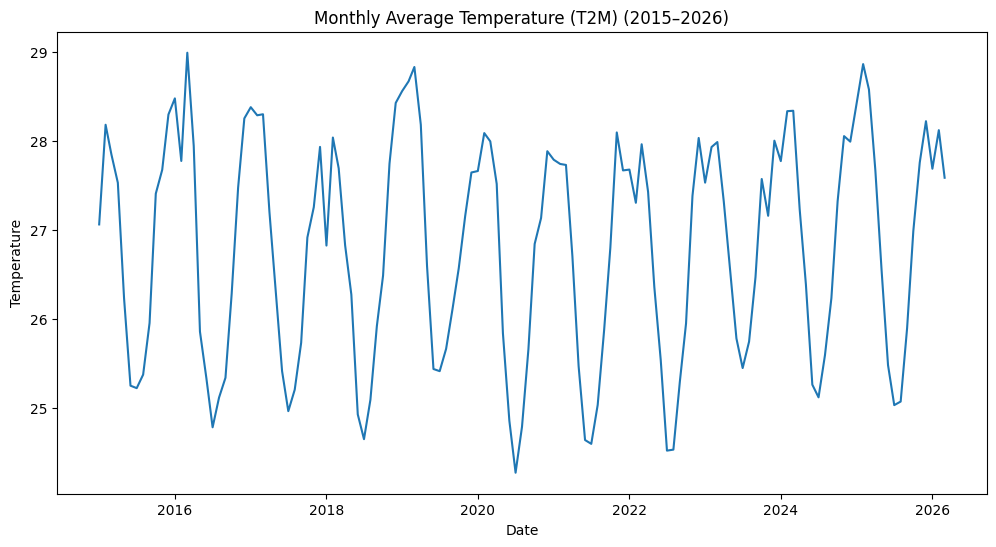

In [10]:
monthly_t2m = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

#Create a proper date for plotting
monthly_t2m["Date"] = pd.to_datetime(monthly_t2m["YEAR"].astype(str) + "-" + monthly_t2m["Month"].astype(str))

#Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_t2m["Date"], monthly_t2m["T2M"])
plt.title("Monthly Average Temperature (T2M) (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()



Annotate Warmest & Coolest Months

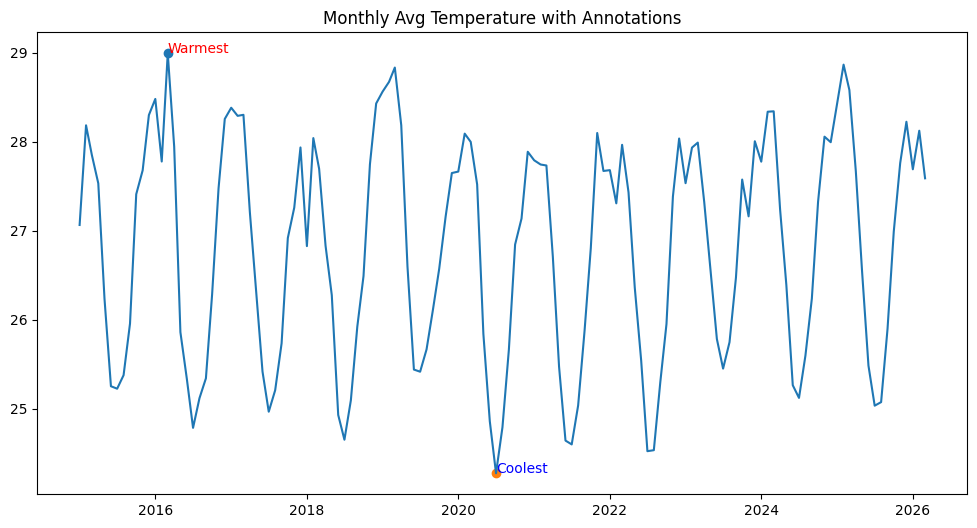

In [11]:
#Annotate Warmest & Coolest Months
max_row = monthly_t2m.loc[monthly_t2m["T2M"].idxmax()]
min_row = monthly_t2m.loc[monthly_t2m["T2M"].idxmin()]

plt.figure(figsize=(12,6))
plt.plot(monthly_t2m["Date"], monthly_t2m["T2M"])

plt.scatter(max_row["Date"], max_row["T2M"])
plt.text(max_row["Date"], max_row["T2M"], "Warmest", color="red")

plt.scatter(min_row["Date"], min_row["T2M"])
plt.text(min_row["Date"], min_row["T2M"], "Coolest", color="blue")

plt.title("Monthly Avg Temperature with Annotations")
plt.show()

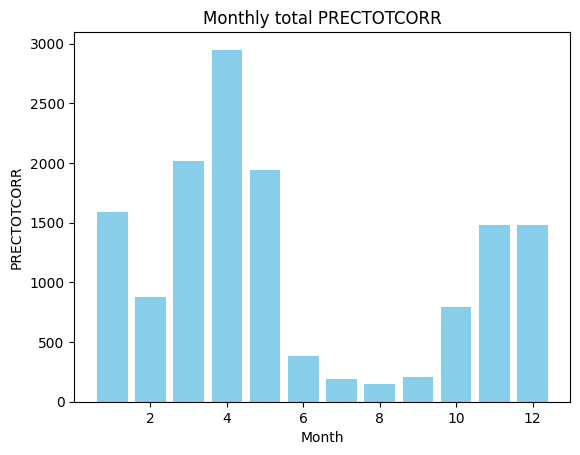

In [12]:

#Monthly Total PRECTOTCORR (Bar Chart)
monthly_precip = df.groupby('Month')['PRECTOTCORR'].sum()
plt.figure()
plt.bar(monthly_precip.index, monthly_precip.values, color='skyblue')
plt.title('Monthly total PRECTOTCORR')
plt.xlabel('Month')
plt.ylabel('PRECTOTCORR')
plt.show()



## Correlation

Correlation Heatmap

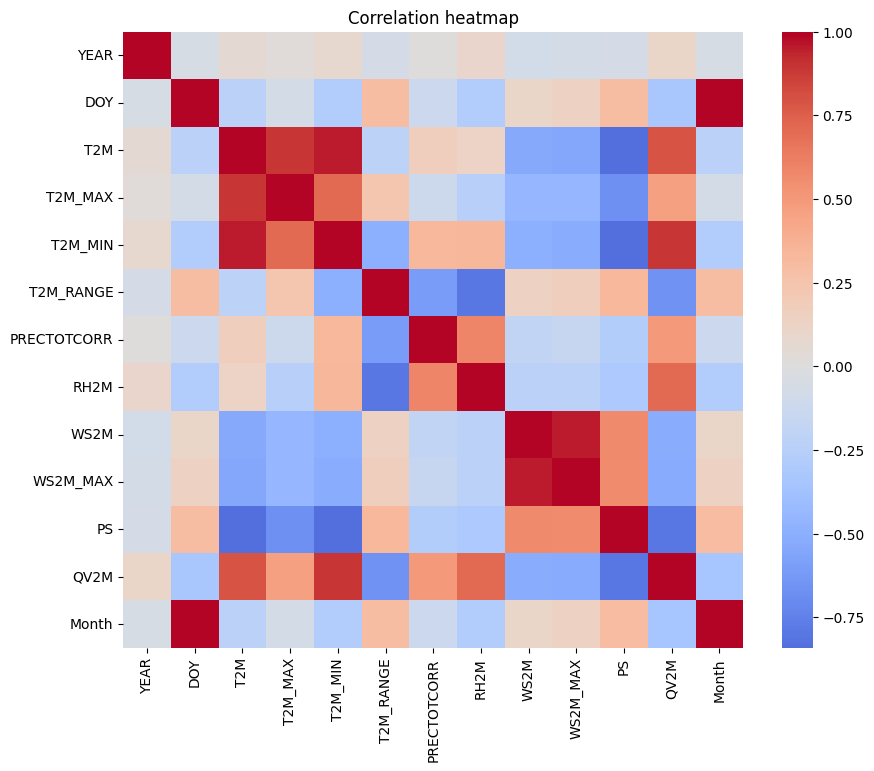

In [13]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation heatmap')
plt.show()

Scatter Plot: T2M vs RH2M

DOY       Month    0.996557
Month     DOY      0.996557
WS2M_MAX  WS2M     0.951308
dtype: float64


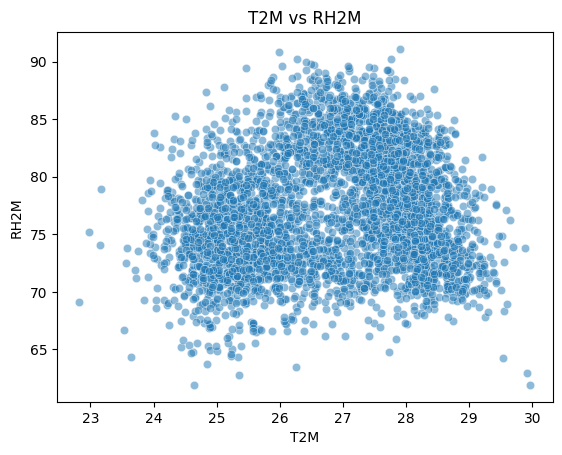

In [14]:
print(corr.unstack().sort_values(ascending=False)[len(corr):len(corr)+3])
plt.figure()
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5)
plt.title('T2M vs RH2M')
plt.show()

Scatter Plot: T2M_RANGE vs WS2M

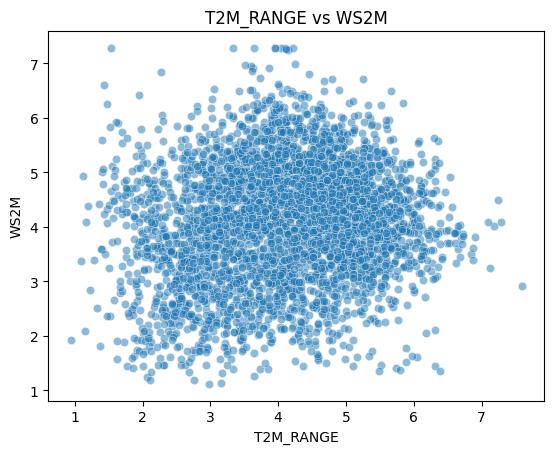

In [15]:

plt.figure()
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5)
plt.title('T2M_RANGE vs WS2M')
plt.show()


## Distribution

Histogram of PRECTOTCORR

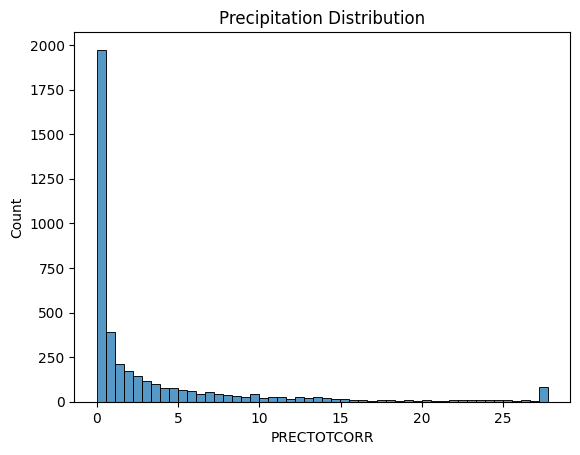

In [16]:
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Precipitation Distribution")
plt.show()

If skewed → log scale
Right-skewed (positively skewed)

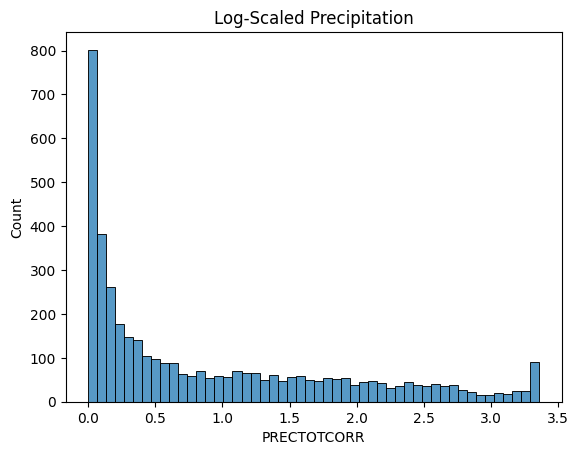

In [17]:
sns.histplot(np.log1p(df["PRECTOTCORR"]), bins=50)
plt.title("Log-Scaled Precipitation")
plt.show()

Bubble Chart

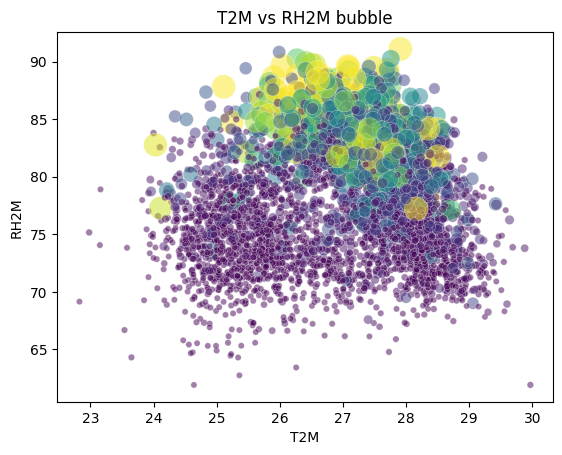

In [18]:
plt.figure()
df2 = df[df['PRECTOTCORR'] > 0]
sns.scatterplot(data=df2, x='T2M', y='RH2M', size='PRECTOTCORR', sizes=(20, 300), alpha=0.5, hue='PRECTOTCORR', palette='viridis', legend=False)
plt.title('T2M vs RH2M bubble')
plt.show()